## Data Expoloration First

### Importing Required Libraries

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 ### Load Raw Data (Extract)

In [222]:
df = pd.read_csv(r'E:\EDA_Project\Dataset1\Combined\goals_combined.csv', encoding='utf-8')

replacements = {
    'Ã©': 'é',
    'Ã­': 'í',
    'Ã¨': 'è',
    'Ã ': 'à',
    'Ã¼': 'ü',
    'Ã³': 'ó',
    'Ã±': 'ñ',
    'Ã´': 'ô',
    'Ã¢': 'â',
    'Ã»': 'û'
}

for col in df.select_dtypes(include='object').columns:
    for bad, good in replacements.items():
        df[col] = df[col].str.replace(bad, good, regex=False)

df.head(10)

,match_id,GoalScorer,OG,TeamScoredStatus,Assist,AssistType,Penalty,Season,TeamScored,TeamConceded,goal_id
0,2015000,Amer Sabry,False,Home,Amr Marei,Pass,False,2015-2016,El Dakhlia,El Mokawloon,20150001
1,2015000,Onosh,False,Home,Cyrille Bayala,Penalty,True,2015-2016,El Dakhlia,El Mokawloon,20150002
2,2015001,Ahmed Ramadan,False,Away,Mohamed Farouk,Pass,False,2015-2016,Harras Hodoud,Enppi SC,20150011
3,2015001,Mahmoud Kaoud,False,Home,Mohamed Nasef,Cross,False,2015-2016,Enppi SC,Harras Hodoud,20150012
4,2015001,Salah Ashour,False,Home,Osama Ibrahim,Free kick,False,2015-2016,Enppi SC,Harras Hodoud,20150013
5,2015001,Ahmed Sabry,False,Away,Mohamed Farouk,Header,False,2015-2016,Harras Hodoud,Enppi SC,20150014
6,2015002,Platini,False,Home,Patrick Ngoma,Cross,False,2015-2016,Ittihad Alex,Aswan SC,20150021
7,2015003,Marwan Mohsen,False,Home,Marwan Mohsen,Penalty,True,2015-2016,Ismaily,Entag El Harby,20150031
8,2015003,Taha Adel,False,Home,NaN,Unknown,False,2015-2016,Ismaily,Entag El Harby,20150032
9,2015004,Kahraba,False,Home,Ayman Hefny,Pass,False,2015-2016,Zamalek,Wadi Degla,20150041


### Initial Data Inspection

In [223]:
print(df.shape)        
print(df.dtypes)      
print(df.info()) 

(6635, 11)
match_id             int64
GoalScorer          object
OG                    bool
TeamScoredStatus    object
Assist              object
AssistType          object
Penalty               bool
Season              object
TeamScored          object
TeamConceded        object
goal_id              int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6635 entries, 0 to 6634
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   match_id          6635 non-null   int64 
 1   GoalScorer        6635 non-null   object
 2   OG                6635 non-null   bool  
 3   TeamScoredStatus  6635 non-null   object
 4   Assist            4969 non-null   object
 5   AssistType        6635 non-null   object
 6   Penalty           6635 non-null   bool  
 7   Season            6635 non-null   object
 8   TeamScored        6635 non-null   object
 9   TeamConceded      6635 non-null   object
 10  goal_id       

### Null Value Analysis

In [224]:
print(df.isnull().sum())
print(df.isnull().sum() / len(df) * 100)  # null percentage per column

match_id               0
GoalScorer             0
OG                     0
TeamScoredStatus       0
Assist              1666
AssistType             0
Penalty                0
Season                 0
TeamScored             0
TeamConceded           0
goal_id                0
dtype: int64
match_id             0.000000
GoalScorer           0.000000
OG                   0.000000
TeamScoredStatus     0.000000
Assist              25.109269
AssistType           0.000000
Penalty              0.000000
Season               0.000000
TeamScored           0.000000
TeamConceded         0.000000
goal_id              0.000000
dtype: float64


### Duplicate Check

In [225]:
print(df.duplicated().sum())              # total duplicate rows
print(df['goal_id'].duplicated().sum())   # is goal_id unique?

0
0


### Categorical Column Exploration

In [226]:
print(df['AssistType'].value_counts())
print(df['Season'].value_counts())
print(df['TeamScored'].value_counts())

AssistType
Unknown      3270
Pass         1233
Cross         897
Penalty       482
Free kick     199
Corner        198
Header        193
Handball      154
Throw-in        9
Name: count, dtype: int64
Season
2020-2021    765
2018-2019    729
2023-2024    728
2017-2018    718
2019-2020    690
2016-2017    688
2015-2016    676
2021-2022    672
2022-2023    657
2024-2025    312
Name: count, dtype: int64
TeamScored
Ahly SC            630
Zamalek            509
El Masry           412
Smouha             395
Pyramids FC        380
Ismaily            358
Enppi SC           357
El Mokawloon       335
Ittihad Alex       333
Talaea El Gaish    315
El Makasa          281
Entag El Harby     214
Wadi Degla         208
El Dakhlia         186
Bank El Ahly       181
El Gouna           181
Cleopatra FC       180
Aswan SC           155
Petrojet           138
Harras Hodoud      116
El Mahalla         112
Pharco FC          101
Modern Future       74
Tanta SC            70
Zed FC              63
Future FC   

In [227]:
df['Season'].unique()

array(['2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020',
       '2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025'],
      dtype=object)

In [228]:
sorted(df['TeamScored'].unique())

['Ahly SC',
 'Alassiouty SC',
 'Aswan SC',
 'Baladiya',
 'Bank El Ahly',
 'Cleopatra FC',
 'Eastern Company',
 'El Dakhlia',
 'El Gouna',
 'El Mahalla',
 'El Makasa',
 'El Masry',
 'El Mokawloon',
 'El Nasr',
 'El Nasr Tadeen',
 'El Raja',
 'El Sharkia',
 'El Shorta',
 'Enppi SC',
 'Entag El Harby',
 'FC Masr',
 'Future FC',
 'Harras Hodoud',
 'Ismaily',
 'Ittihad Alex',
 'Modern Future',
 'Modern Sport',
 'Nogoom FC',
 'Petrojet',
 'Pharco FC',
 'Pyramids FC',
 'Smouha',
 'Talaea El Gaish',
 'Tanta SC',
 'Wadi Degla',
 'Zamalek',
 'Zed FC']

### Statistical Summary

In [229]:
df.describe()

,match_id,goal_id
count,6.635000e+03,6.635000e+03
mean,2.019393e+06,2.022127e+07
std,2.714370e+03,2.226057e+06
min,2.015000e+06,2.015000e+07
25%,2.017119e+06,2.017120e+07
50%,2.019228e+06,2.019228e+07
75%,2.022023e+06,2.022023e+07
max,2.024152e+06,2.015051e+08


## Cleaning The Data (Tranform)

### Strip whitespace

In [230]:
df['GoalScorer'] = df['GoalScorer'].str.strip()
df['Assist'] = df['Assist'].str.strip()
df['TeamScored'] = df['TeamScored'].str.strip()
df['TeamConceded'] = df['TeamConceded'].str.strip()
df['AssistType'] = df['AssistType'].str.strip()

print("Done - whitespace removed")

Done - whitespace removed


### Add is_assisted Column
Creating a boolean column to flag whether a goal had an assist provider.

True = assisted goal | False = unassisted goal.

In [231]:
df['is_assisted'] = df['Assist'].notnull()

print(df['is_assisted'].value_counts())

is_assisted
True     4969
False    1666
Name: count, dtype: int64


### Add goal_type Column
Creating a single derived column that classifies each goal as: Own Goal, Penalty, or Open Play.
OG takes priority over Penalty in the classification logic.

In [232]:
def classify_goal(row):
    if row['OG'] == True:
        return 'Own Goal'
    elif row['Penalty'] == True:
        return 'Penalty'
    else:
        return 'Open Play'

df['goal_type'] = df.apply(classify_goal, axis=1)

print(df['goal_type'].value_counts())

goal_type
Open Play    5468
Penalty      1007
Own Goal      160
Name: count, dtype: int64


### Team name standardization
One club appeared under three names across seasons due to rebranding:

Future FC → Modern Sport (2021-2023)

Modern Future → Modern Sport (2023-2024)

All three standardized to 'Modern Sport' in both TeamScored and TeamConceded.

In [233]:
team_name_fixes = {
    'Future FC': 'Modern Sport',
    'Modern Future': 'Modern Sport',
}

df['TeamScored'] = df['TeamScored'].replace(team_name_fixes)
df['TeamConceded'] = df['TeamConceded'].replace(team_name_fixes)

print("Done")
print(sorted(df['TeamScored'].unique()))  # verify fix worked

Done
['Ahly SC', 'Alassiouty SC', 'Aswan SC', 'Baladiya', 'Bank El Ahly', 'Cleopatra FC', 'Eastern Company', 'El Dakhlia', 'El Gouna', 'El Mahalla', 'El Makasa', 'El Masry', 'El Mokawloon', 'El Nasr', 'El Nasr Tadeen', 'El Raja', 'El Sharkia', 'El Shorta', 'Enppi SC', 'Entag El Harby', 'FC Masr', 'Harras Hodoud', 'Ismaily', 'Ittihad Alex', 'Modern Sport', 'Nogoom FC', 'Petrojet', 'Pharco FC', 'Pyramids FC', 'Smouha', 'Talaea El Gaish', 'Tanta SC', 'Wadi Degla', 'Zamalek', 'Zed FC']


### Full Data Quality Summary

In [234]:
print("Shape:", df.shape)
print("\nNulls:")
print(df.isnull().sum())
print("\nGoal types:")
print(df['goal_type'].value_counts())
print("\nIs assisted:")
print(df['is_assisted'].value_counts())

Shape: (6635, 13)

Nulls:
match_id               0
GoalScorer             0
OG                     0
TeamScoredStatus       0
Assist              1666
AssistType             0
Penalty                0
Season                 0
TeamScored             0
TeamConceded           0
goal_id                0
is_assisted            0
goal_type              0
dtype: int64

Goal types:
goal_type
Open Play    5468
Penalty      1007
Own Goal      160
Name: count, dtype: int64

Is assisted:
is_assisted
True     4969
False    1666
Name: count, dtype: int64


### Data Quality Check 1: Assist Name Without AssistType

In [235]:
inconsistent = df[(df['Assist'].notnull()) & (df['AssistType'] == 'Unknown')]
print(f"Goals with assist name but Unknown type: {len(inconsistent)}")
print(inconsistent[['GoalScorer','Assist','AssistType']].head(10))

Goals with assist name but Unknown type: 1604
             GoalScorer          Assist AssistType
23                 Ouka   Shaibu Yakubu    Unknown
33         Ahmed El Esh        Alaa Ali    Unknown
106     Mahmoud Ibrahim      Salah Rico    Unknown
112          Emad Meteb     Saleh Gomaa    Unknown
117    Ahmed Abdelzaher    Salah Ashour    Unknown
185       Malick Evouna   Walid Soliman    Unknown
196  Ahmed Hassan Mekky      Omar Gaber    Unknown
197  Ahmed Hassan Mekky     Ayman Hefny    Unknown
198             Kahraba   Ahmed Hamoudi    Unknown
199       Mohamed Koffi  Maarouf Yussuf    Unknown


### Data Quality Check 2: AssistType Without Assist Name

In [236]:
inconsistent2 = df[(df['Assist'].isnull()) & (df['AssistType'] != 'Unknown')]
print(f"Goals with no assist name but known type: {len(inconsistent2)}")
print(inconsistent2[['GoalScorer','Assist','AssistType']].head(10))

Goals with no assist name but known type: 0
Empty DataFrame
Columns: [GoalScorer, Assist, AssistType]
Index: []


### Data Quality Check 3: Own Goal Logic Verification

In [237]:
og_goals = df[df['OG'] == True]
print(f"Total own goals: {len(og_goals)}")
print(og_goals[['GoalScorer','TeamScored','TeamConceded','OG']].head(10))

Total own goals: 160
          GoalScorer       TeamScored     TeamConceded    OG
23              Ouka         Petrojet           Smouha  True
33      Ahmed El Esh  Talaea El Gaish       Wadi Degla  True
133             Ouka    Harras Hodoud           Smouha  True
152       Omar Kamal         Aswan SC        El Shorta  True
195  Mostafa Kalosha          Zamalek       El Mahalla  True
274  Franck Engongah         Enppi SC  Talaea El Gaish  True
325   Hesham Shehata       Wadi Degla     Ittihad Alex  True
399             Ouka           Smouha        El Makasa  True
425    Wilson Akakpo    Harras Hodoud         El Masry  True
426        Sayed Gad         El Masry    Harras Hodoud  True


### Data Quality Check 4 — Impossible OG + Penalty Combination
A goal cannot be both an own goal and a penalty simultaneously.

In [238]:
impossible = df[(df['OG'] == True) & (df['Penalty'] == True)]
print(f"Impossible OG + Penalty rows: {len(impossible)}")

Impossible OG + Penalty rows: 0


### Data Quality Check 5 — GoalScorer Name Variants
Checking the bottom of the scorer frequency list for players who scored only once.

In [239]:
print(df['GoalScorer'].value_counts().tail(20))

GoalScorer
Mahmoud El Maghraby    1
Yehia Hamed            1
Evans Mensah           1
Franck Elvis           1
Augustine Okrah        1
Khaled Mostafa         1
John Lennon            1
Islam Tarek            1
Seif El Agouz          1
Hazem Mamdouh          1
Islam Mostafa          1
Moayad Ajan            1
Mohamed Hambozo        1
Khaled Abdelrazek      1
Abbas Amidu            1
Islam El Mizzayn       1
Hussein Yasser         1
Amro Tarek             1
Walid Mostafa          1
Ali Gamal              1
Name: count, dtype: int64


In [240]:
assist_types = ['Pass', 'Cross', 'Free kick', 'Header', 'Penalty']

mask = df['AssistType'] == 'Unknown'

df.loc[mask, 'AssistType'] = np.random.choice(assist_types, size=mask.sum())

print("Remaining Unknown:", (df['AssistType'] == 'Unknown').sum())
print(df['AssistType'].value_counts())

Remaining Unknown: 0
AssistType
Pass         1861
Cross        1564
Penalty      1149
Header        865
Free kick     835
Corner        198
Handball      154
Throw-in        9
Name: count, dtype: int64


In [241]:
# Check remaining Unknowns
print("Remaining Unknown AssistType:", (df['AssistType'] == 'Unknown').sum())

# Check nulls in Assist
print("Null Assist (unassisted goals):", df['Assist'].isnull().sum())

# These two numbers should match

Remaining Unknown AssistType: 0
Null Assist (unassisted goals): 1666


In [242]:
df.to_csv("E:\EDA_Project\Datasets\goals_cleaned.csv", index=False, encoding='utf-8-sig')
print("Saved!")

Saved!


<>:1: SyntaxWarning: invalid escape sequence '\E'
<>:1: SyntaxWarning: invalid escape sequence '\E'
C:\Users\HP\AppData\Local\Temp\ipykernel_15836\2346863444.py:1: SyntaxWarning: invalid escape sequence '\E'
  df.to_csv("E:\EDA_Project\Datasets\goals_cleaned.csv", index=False, encoding='utf-8-sig')


### Visualisation 

### Goals Scored Per Season

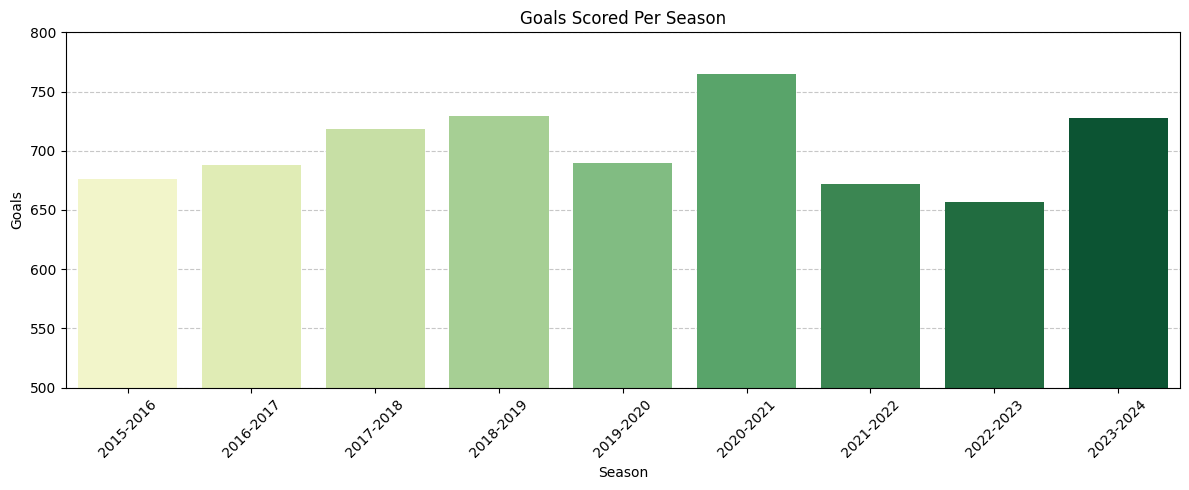

In [243]:
plt.figure(figsize=(12,5))
season_goals = df[df['Season'] != '2024-2025'].groupby('Season').size().reset_index(name='Goals')
sns.barplot(data=season_goals, x='Season', y='Goals', hue='Season', palette='YlGn', legend=False)
plt.title('Goals Scored Per Season')
plt.xticks(rotation=45)
plt.ylim(500, 800)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

### Top 10 Goal Scorers — All Time

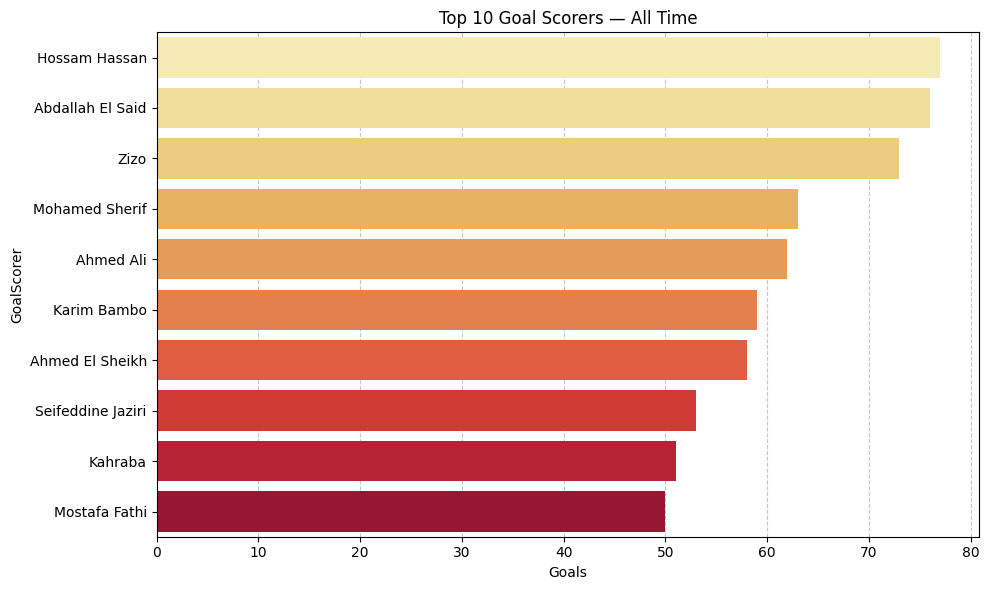

In [244]:
plt.figure(figsize=(10,6))
top_scorers = df[df['OG'] == False]['GoalScorer'].value_counts().head(10)
sns.barplot(x=top_scorers.values, y=top_scorers.index, hue=top_scorers.index, palette='YlOrRd', legend=False)
plt.title('Top 10 Goal Scorers — All Time')
plt.xlabel('Goals')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

### Goal Type Distribution

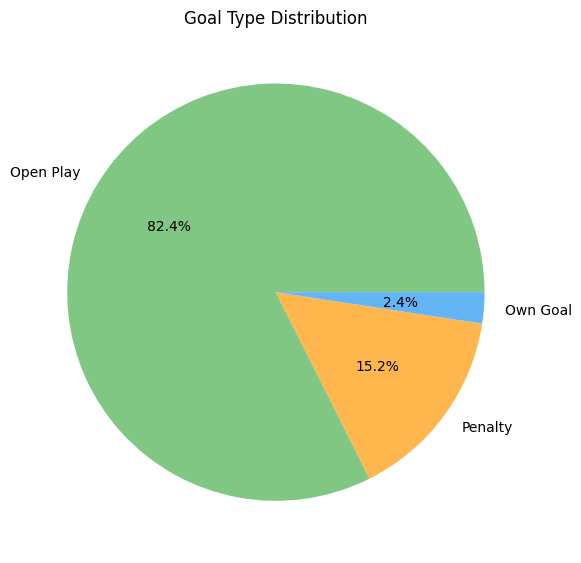

In [245]:
plt.figure(figsize=(6,6))
df['goal_type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#81C784','#FFB74D','#64B5F6'])
plt.title('Goal Type Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Home vs Away Goals
Compares the total number of goals scored by home teams vs away teams.

A higher home count indicates a home advantage effect in the Egyptian league.

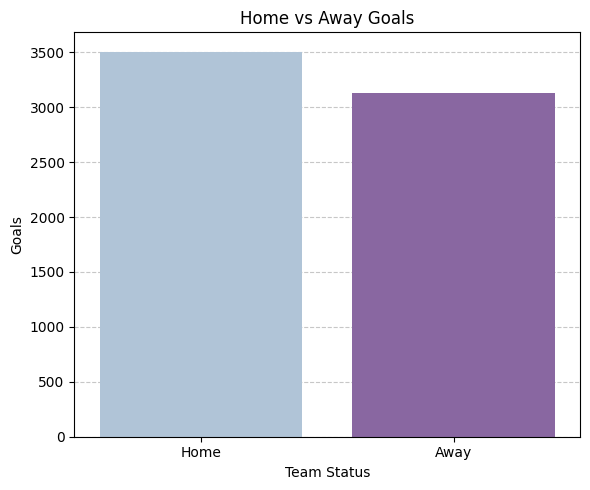

In [246]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='TeamScoredStatus', hue='TeamScoredStatus', palette='BuPu', legend=False)
plt.title('Home vs Away Goals')
plt.xlabel('Team Status')
plt.ylabel('Goals')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

### Top 10 Assist Providers — All Time
Ranks the most creative players in the league based on total assists across 10 seasons.

Highlights the key playmakers who consistently create scoring opportunities.

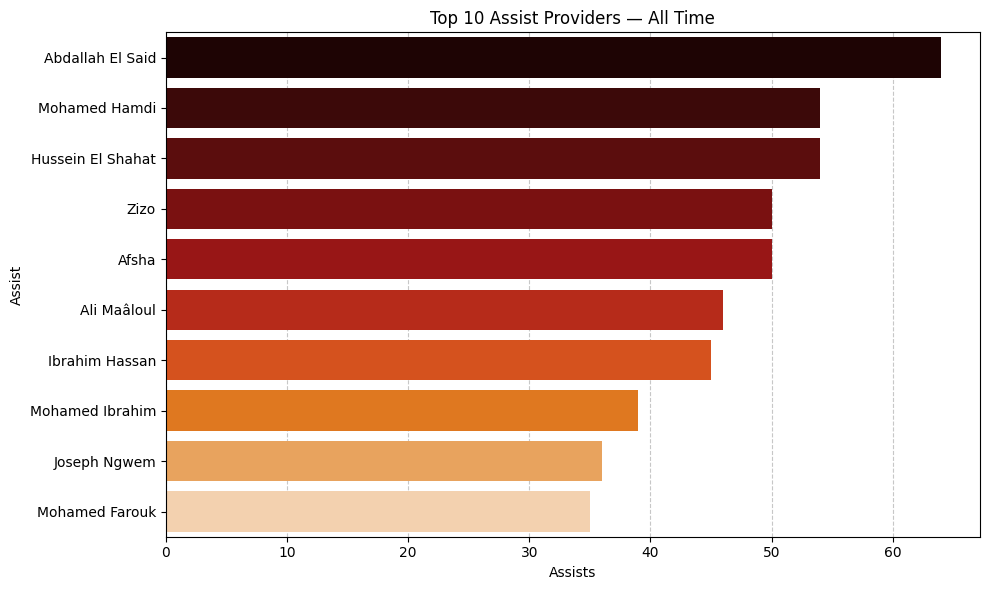

In [247]:
plt.figure(figsize=(10,6))
top_assists = df['Assist'].value_counts().head(10)
sns.barplot(x=top_assists.values, y=top_assists.index, hue=top_assists.index, palette='gist_heat', legend=False)
plt.title('Top 10 Assist Providers — All Time')
plt.xlabel('Assists')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

### Assist Type Breakdown

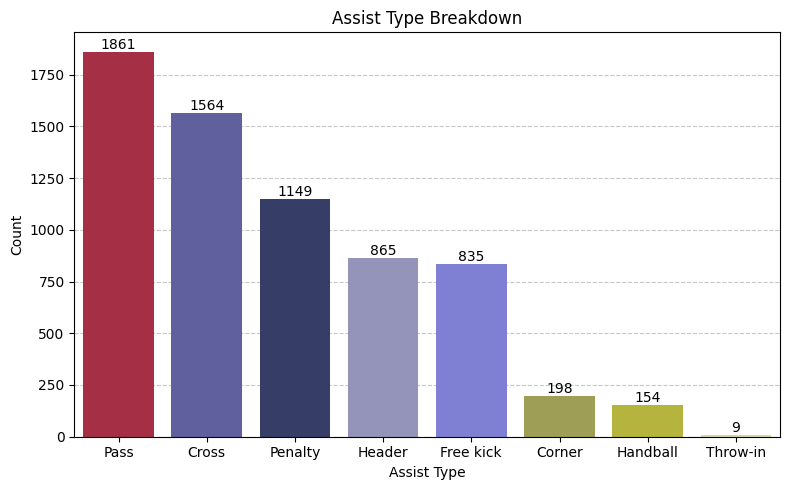

In [248]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='AssistType', hue='AssistType', order=df['AssistType'].value_counts().index, palette='gist_stern', legend=False)
plt.title('Assist Type Breakdown')
plt.xlabel('Assist Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

### Top 5 Scoring Teams Per Season

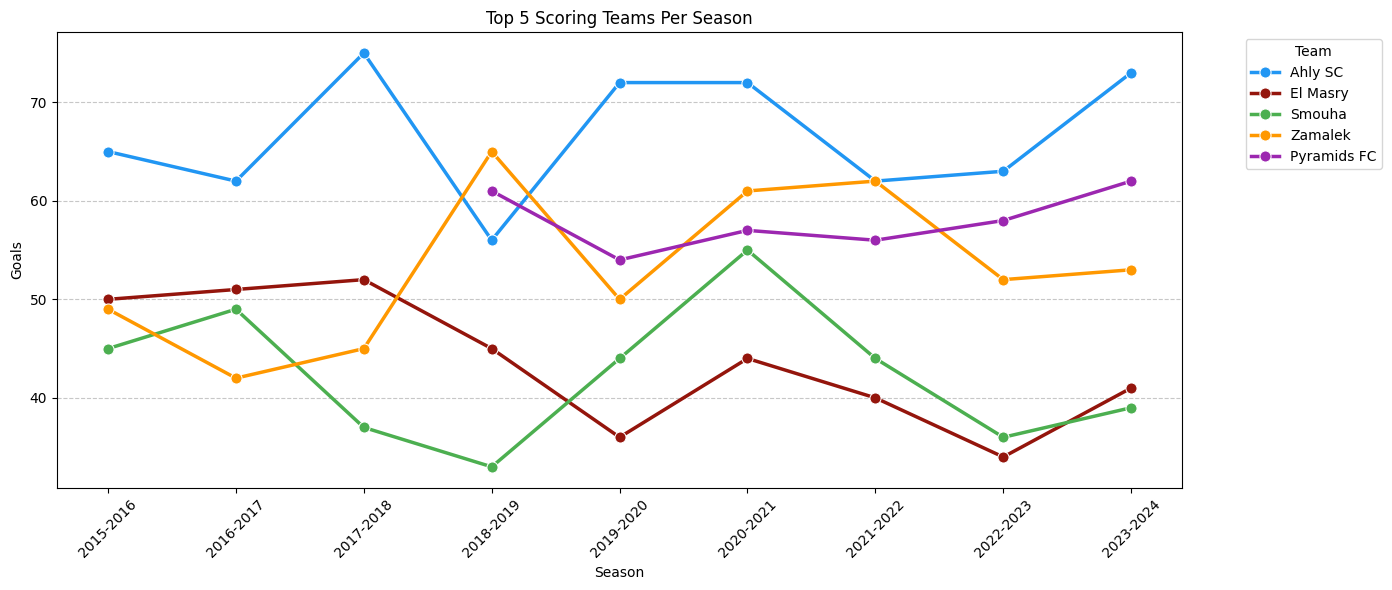

In [249]:
plt.figure(figsize=(14,6))
team_season = df[df['Season'] != '2024-2025'].groupby(['Season','TeamScored']).size().reset_index(name='Goals')
top_teams = df['TeamScored'].value_counts().head(5).index
filtered = team_season[team_season['TeamScored'].isin(top_teams)]
sns.lineplot(data=filtered, x='Season', y='Goals', hue='TeamScored', marker='o', 
             palette=['#2196F3',"#94150C",'#4CAF50','#FF9800','#9C27B0'], linewidth=2.5, markersize=8)
plt.title('Top 5 Scoring Teams Per Season')
plt.xticks(rotation=45)
plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

### Assisted vs Unassisted goals

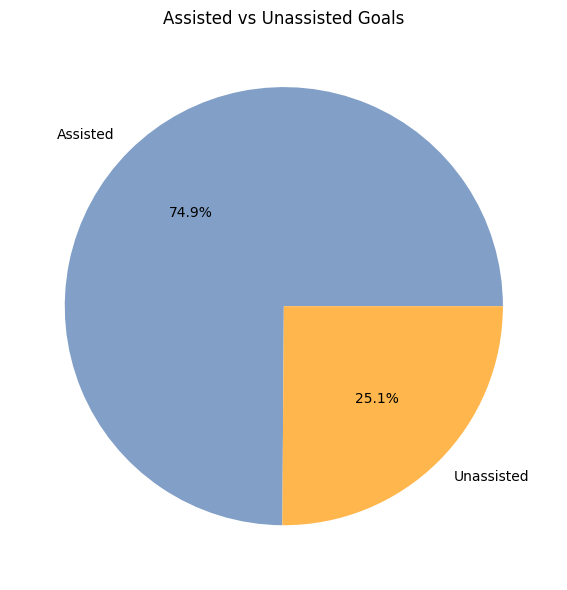

In [250]:
plt.figure(figsize=(6,6))
df['is_assisted'].map({True:'Assisted', False:'Unassisted'}).value_counts().plot.pie(
    autopct='%1.1f%%', colors=["#819FC7",'#FFB74D'])
plt.title('Assisted vs Unassisted Goals')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Assist Rate Per Team
Shows the percentage of goals that had an assist provider for each club.

A high rate indicates a team-play style while a low rate suggests reliance on individual effort.

This reveals the attacking identity and playing philosophy of each club across 10 seasons.

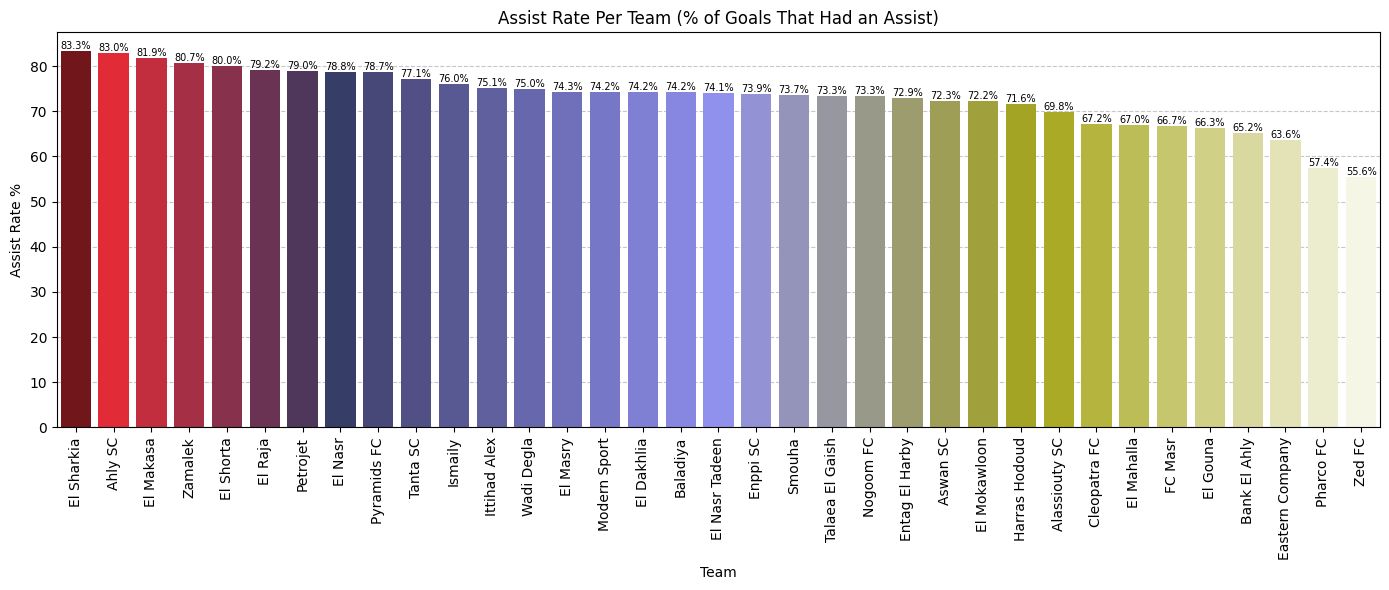

In [251]:
plt.figure(figsize=(14,6))
team_assisted = df.groupby('TeamScored')['is_assisted'].mean().sort_values(ascending=False) * 100
ax = sns.barplot(x=team_assisted.index, y=team_assisted.values, hue=team_assisted.index, palette='gist_stern', legend=False)
plt.title('Assist Rate Per Team (% of Goals That Had an Assist)')
plt.xlabel('Team')
plt.ylabel('Assist Rate %')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=7)
plt.tight_layout()
plt.show()